In [104]:
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB 
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


#### Conditional Probability:

probability of any event A, given any other event B has occured
i.e:
P(A and B)= P(A) * P(B/A) , isei kehte hai conditional probability
for example: 
if i have a box of 4 red balls and 3 green balls
then the probability of picking first, the red ball and thereafter picking the green ball(then the probability of this entire event will be):

P(R and G)= P(R)*P(G/R) [prob. of red * prob of green given red, (4/7)*(3/6) ] 

#### DERIVATION OF BAYES THEOREM:(SIMPLE MATH AHEAD!)

P(A and B) = P(B and A)  [commutative law ki wajah se]
P(A) * P(B/A) = P(B) * P(A/B)

P(B/A) = (P(B) * P(A/B))/ P(A)  ISI LINE KO KEHTE HAI _BAYES THEOREM_

THEN HOW DO WE USE IT :
suppose we have few independent features (coloumns / different xs) and a output feature(y)
(i.e. that thing which we want to find or predict should be 'y'-output feature)

x1  x2  x3  y
--  --  --  --
--  --  --  --
--  --  --  --
--  --  --  --

here:
P(y/x1, x2, x3) = (P(y) * P(x1*x2*x3 / y) )/P(x1, x2, x3)
[Prob. of y(B)
given x1, x2, x3
( x1, x2, x3 all together are A)]

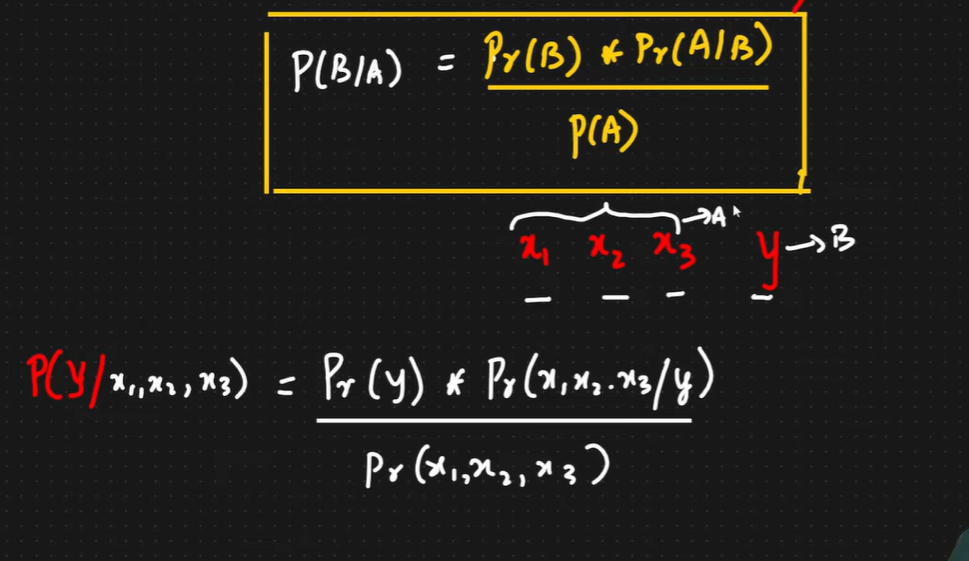

#### WHY DO WE CALL IT NAIVE:
we call it "naive" because we make a naive assumption that all x features are independent of each other
even if they are not:
for example we will use TITANIC dataset to predict whether the passenger survived the tragedy or not
based on sex, class, age, cabin , fare etc.
now cabin and fare are directly related to each other as more the fare better will be the class you get to travel in, but we assume that these are independent feature.


#### USAGE:
NAIVE BAYES  is used in:

email spam detection

character recognisation

weather forecasting

face recognition

news article categorisation

In [105]:
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

In [106]:
titanic=fetch_openml(name="titanic", version=1, as_frame=True)
#version=1 fixes which Titanic dataset you load, and as_frame=True
#  controls the format you get back (pandas DataFrame instead of NumPy arrays).

df=titanic.frame


In [107]:
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [108]:
#now there are certain coloumns such as "name", "passenger id", "sib sp",
#  "ticket", "embarked", "parch", "cabin" which have no relation with wehther someone survived or not
#like the name has nothing to do with whether the person will survive or not

# therefore we will drop these coloumn so that the dataset which we are working with becomes a bit simpler

df.drop(['name', 'sibsp', 'home.dest', 'embarked', 'boat', 'parch', 'body', 'cabin', 'ticket'], axis='columns', inplace=True)

# Why axis='columns' is used
# DataFrame.drop() can drop rows or columns, and by default it assumes axis=0 (rows).
# When you call df.drop(['name', 'sibsp', ...]) without specifying axis, pandas thinks
# those labels are row indices and will either fail or drop rows, not columns.
# Setting axis='columns' (or axis=1) switches it to “drop these from the column axis”.

df.head()

,pclass,survived,sex,age,fare
0,1,1,female,29.0000,211.3375
1,1,1,male,0.9167,151.5500
2,1,0,female,2.0000,151.5500
3,1,0,male,30.0000,151.5500
4,1,0,female,25.0000,151.5500


In [109]:
#now i want to separate the target variable which is "survived" in different series

target = df.survived

# and my dependent variables in inputs
inputs =df.drop('survived', axis='columns')
#so that every thing that is evry columns gets saved in inputs except 'survived' column
# because that have been droped

In [110]:
#there is also one problem that is the 'sex' coloumn is text
# and machine -learning algorothms only processes numerical data
# therefore we will have to convert it into that

# here we are going to use get_dummies (one hot encoder)

dummies = pd.get_dummies(inputs.sex, dtype=int) #by default get_dummies return true / false not 0/1
dummies.head(3)

,female,male
0,1,0
1,0,1
2,1,0


In [111]:
#now we are going to append these dummy coloumns in our
# input dataframes and we can do that by using
# pandas "concat" function

inputs = pd.concat([inputs, dummies], axis='columns')
inputs.head()
# pd.concat([inputs, dummies], ...) combines the two objects in the list: the original
# feature DataFrame inputs and the new dummy columns dummies.
# axis='columns' (same as axis=1) means concatenate horizontally,
# so all columns from dummies are appended as new columns to inputs, aligned by index.
# The result is assigned back to inputs, so now inputs contains its 
# original features plus the one‑hot columns for sex.


,pclass,sex,age,fare,female,male
0,1,female,29.0000,211.3375,1,0
1,1,male,0.9167,151.5500,0,1
2,1,female,2.0000,151.5500,1,0
3,1,male,30.0000,151.5500,0,1
4,1,female,25.0000,151.5500,1,0


In [112]:
#now i dont want to have the 'sex' column as i have the dummy coloumns in place of that

inputs.drop('sex', axis='columns', inplace=True)


In [113]:
inputs.head(3)

,pclass,age,fare,female,male
0,1,29.0000,211.3375,1,0
1,1,0.9167,151.5500,0,1
2,1,2.0000,151.5500,1,0


In [114]:
#now i want to findout whether any coloumn have any null values or not
# for that i will use isnull().sum()

inputs.isnull().sum()

pclass      0
age       263
fare        1
female      0
male        0
dtype: int64

In [115]:
inputs=inputs.fillna({'age':inputs['age'].mean(), 'fare':inputs['fare'].mean()})

# Option 1: In-place (no assignment)
# inputs.fillna(
#     {'age': inputs['age'].mean(),
#      'fare': inputs['fare'].mean()},
#     inplace=True
# )
# inputs.head(2)

# Option 2: Return new DataFrame (no inplace)
# inputs = inputs.fillna(
#     {'age': inputs['age'].mean(),
#      'fare': inputs['fare'].mean()}
# )
# inputs.head(2)

In [116]:
inputs.head()

,pclass,age,fare,female,male
0,1,29.0000,211.3375,1,0
1,1,0.9167,151.5500,0,1
2,1,2.0000,151.5500,1,0
3,1,30.0000,151.5500,0,1
4,1,25.0000,151.5500,1,0


import pandas as pd
from sklearn.datasets import fetch_openml

titanic=fetch_openml(name="titanic", version=1, as_frame=True)
df=titanic.frame
df.drop(['name', 'sibsp', 'home.dest', 'embarked', 'boat', 'parch', 'body', 'cabin'], axis='columns', inplace=True)
target = df.survived
inputs =df.drop('survived', axis='columns')
dummies = pd.get_dummies(inputs.sex, dtype=int) 
inputs = pd.concat([inputs, dummies], axis='columns')
inputs.drop('sex', axis='columns', inplace=True)

inputs.isnull().sum()
inputs=inputs.fillna({'age':inputs['age'].mean(), 'fare':inputs['fare'].mean()}, inplace=True)
inputs.head(2)

In [138]:
X_train, X_test, y_train, y_test=train_test_split(
    inputs, target, test_size=0.2
)

In [139]:
#we can also check the distribution of X_train and X_test
#it could be seen that 1309 have been divided into 1047(80%) and 262(20%)
print(len(X_train))
print(len(X_test))
print(len(inputs))

1047
262
1309


In [140]:
#we can also see indovidually X_train and X_test
X_train

,pclass,age,fare,female,male
757,3,29.881135,16.1000,1,0
812,3,29.881135,7.7500,0,1
1022,3,29.881135,7.8958,0,1
1207,3,10.000000,27.9000,0,1
1278,3,20.000000,7.8542,0,1
...,...,...,...,...,...
1,1,0.916700,151.5500,0,1
657,3,0.750000,19.2583,1,0
529,2,50.000000,26.0000,1,0
1147,3,22.000000,39.6875,1,0


In [141]:
X_test

,pclass,age,fare,female,male
1257,3,9.000000,15.2458,1,0
1101,3,1.000000,39.6875,0,1
511,2,62.000000,9.6875,0,1
1218,3,30.000000,8.0500,0,1
848,3,41.000000,14.1083,0,1
...,...,...,...,...,...
1214,3,29.881135,8.6625,0,1
17,1,50.000000,247.5208,1,0
1304,3,14.500000,14.4542,1,0
396,2,34.000000,23.0000,1,0


In [142]:
model=GaussianNB()

In [143]:
model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [ ]:
# now i will use model.score to meausre how accurqte it is
model.score(X_test, y_test)
# 0.7595419847328244
# this i got for the first time
# for the second time 0.7977099236641222
# for the third time 0.8053435114503816
# now if i run train test slit again i will get a better score


0.8053435114503816

In [145]:
X_test[:10]

,pclass,age,fare,female,male
1257,3,9.000000,15.2458,1,0
1101,3,1.000000,39.6875,0,1
511,2,62.000000,9.6875,0,1
1218,3,30.000000,8.0500,0,1
848,3,41.000000,14.1083,0,1
1215,3,29.881135,7.7500,0,1
602,3,16.000000,20.2500,0,1
618,3,35.000000,8.0500,0,1
987,3,29.881135,7.8792,1,0
659,3,5.000000,19.2583,1,0


In [146]:
y_test[0:10]

1257    1
1101    0
511     0
1218    0
848     0
1215    0
602     0
618     0
987     0
659     1
Name: survived, dtype: category
Categories (2, object): ['0', '1']

In [ ]:
model.predict(X_test[0:10])
# now we can match the output with the output by y_test[0:10]
# the model have predicted some values and these values are quite similar

array(['1', '0', '0', '0', '0', '0', '0', '0', '1', '1'], dtype='<U1')